# Ising model

In [1]:
from numpy.random import uniform
from random import choice, randint
import numpy as np
import matplotlib.pyplot as plt

In [5]:
T = 236
beta = 1 / T
n_iterations = 10**4
N = 10
n_states = N^2

In [3]:
def getRandConf(n):
    S = np.zeros((n, n))
    for i in range(n_states):
        for j in range(n_states):
            S[i][j] = choice([-1,1])
    return S

In [4]:
def getEnergy(S):
    E = 0
    for i in range(n_states):
        for j in range(n_states):
            if i > 0:
                E -= S[i][j] * S[i-1][j]
            if i < n_states - 1:
                E -= S[i][j] * S[i+1][j]
            if j > 0:
                E -= S[i][j] * S[i][j-1]
            if j < n_states - 1:
                E -= S[i][j] * S[i][j+1]
    return E

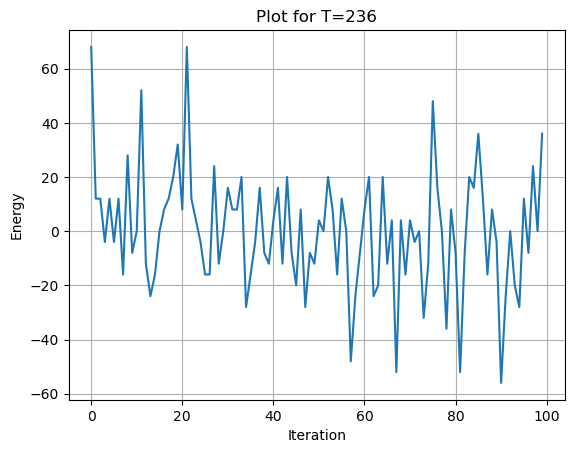

In [7]:
S = getRandConf(n_states)
E = getEnergy(S)

# plt.ion()
# fig, ax = plt.subplots()
# img = ax.imshow(S, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(img, ax=ax)

energies = []
for n_iter in range(n_iterations):
    if n_iter % 100 == 0:
        energies.append(E)
    S_next = S
    (i, j) = randint(0, n_states-1), randint(0, n_states-1)
    S_next[i][j] = -S[i][j]
    E_next = getEnergy(S)
    p_acc = min(1, np.exp(-(beta*(E_next - E))))
    p = uniform(0,1)
    if (p <= p_acc):
        E = E_next
        S = S_next
# print(S)
plt.plot(energies)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title(f"Plot for T={T}")
plt.grid()
plt.show()